In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision.transforms  as transforms
import gzip
import numpy as np
import os
import matplotlib.pyplot as plt
import torchvision.utils as vutils


In [3]:
torch.accelerator.current_accelerator()

device(type='cuda')

In [10]:

class FashionMNISTDataset(Dataset):
    def __init__(self, root, train=True, transform=None):
        self.root = root
        self.transform = transform
        self.train = train
        # 文件路径
        if train:
            self.image_file = os.path.join(root, "train-images-idx3-ubyte.gz")
            self.label_file = os.path.join(root, "train-labels-idx1-ubyte.gz")
        else:
            self.image_file = os.path.join(root, "t10k-images-idx3-ubyte.gz")
            self.label_file = os.path.join(root, "t10k-labels-idx1-ubyte.gz")
        
        # 加载数据
        self.images = self._load_images()
        self.labels = self._load_labels()

    def _load_images(self):
        with gzip.open(self.image_file, 'rb') as f:
            # 读取 idx3-ubyte 格式
            magic = int.from_bytes(f.read(4), 'big')  # 魔数
            num_images = int.from_bytes(f.read(4), 'big')  # 图像数
            rows = int.from_bytes(f.read(4), 'big')  # 行数
            cols = int.from_bytes(f.read(4), 'big')  # 列数
            # 读取所有像素数据
            buffer = f.read(num_images * rows * cols)
            images = np.frombuffer(buffer, dtype=np.uint8).reshape(num_images, rows, cols)
        return torch.tensor(images, dtype=torch.float32)

    def _load_labels(self):
        with gzip.open(self.label_file, 'rb') as f:
            # 读取 idx1-ubyte 格式
            magic = int.from_bytes(f.read(4), 'big')  # 魔数
            num_labels = int.from_bytes(f.read(4), 'big')  # 标签数
            buffer = f.read(num_labels)
            labels = np.frombuffer(buffer, dtype=np.uint8)
        return torch.tensor(labels, dtype=torch.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        # 调整图像维度为 [C, H, W]（PyTorch 标准）
        image = image.unsqueeze(0)  # 从 [H, W] 到 [1, H, W]
        if self.transform:
            image = self.transform(image)
        return image, label

In [11]:
# 路径到你的 .gz 文件
data_path = "/home/fjc/Documents/data/FashionMNIST"

# 图像预处理（归一化到 [0, 1]）
transform = transforms.Compose([
    transforms.Normalize((0.5,), (0.5,))  # FashionMNIST 均值=0.5，标准差=0.5
])

# 加载训练和测试数据集
train_dataset = FashionMNISTDataset(root=data_path, train=True, transform=transform)
test_dataset = FashionMNISTDataset(root=data_path, train=False, transform=transform)

# 创建 DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 检查数据
images, labels = next(iter(train_loader))
print(f"Images shape: {images.shape}")  # [batch_size, 1, 28, 28]
print(f"Labels shape: {labels.shape}")  # [batch_size]

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


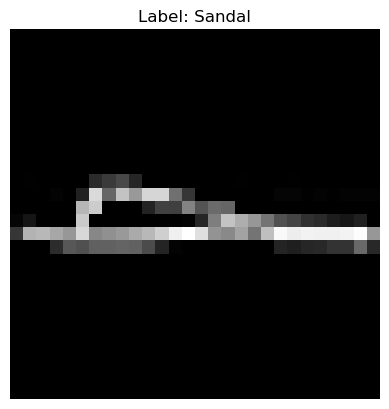

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


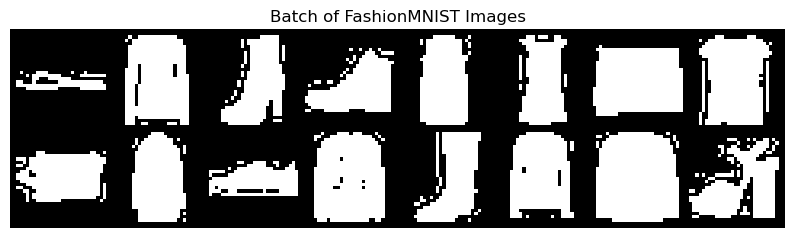

Image 0: Sandal
Image 1: T-shirt/top
Image 2: Ankle boot
Image 3: Ankle boot
Image 4: Coat
Image 5: Dress
Image 6: Bag
Image 7: Shirt
Image 8: Bag
Image 9: Coat
Image 10: Sneaker
Image 11: Pullover
Image 12: Ankle boot
Image 13: Pullover
Image 14: Coat
Image 15: Sandal


In [14]:
# 类名（FashionMNIST 的 10 个类别）
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 显示单张图像
def show_image(image, label, denormalize=True):
    if denormalize:  # 反归一化以显示
        image = image * 0.5 + 0.5  # 从 [-1, 1] 回到 [0, 1]
    image = image.squeeze().numpy()  # 移除通道维度
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {class_names[label]}")
    plt.axis("off")
    plt.show()

# 显示批量图像（网格）
def show_batch(images, labels, denormalize=True):
    if denormalize:
        images = images * 0.5 + 0.5
    grid = vutils.make_grid(images, nrow=8, padding=2, normalize=False)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    plt.title("Batch of FashionMNIST Images")
    plt.axis("off")
    plt.show()
    for i, label in enumerate(labels):
        print(f"Image {i}: {class_names[label]}")

# 示例：显示第一张图像和一个 batch
images, labels = next(iter(train_loader))
show_image(images[0], labels[0])  # 单张
show_batch(images[:16], labels[:16])  # 前 16 张

## 1. torch.nn.functional 
torch.nn.functional主要提供一些功能函数,比如各类loss函数.

In [1]:
import torch.nn.functional as F

loss_func = F.cross_entropy
loss_func

<function torch.nn.functional.cross_entropy(input: torch.Tensor, target: torch.Tensor, weight: Optional[torch.Tensor] = None, size_average: Optional[bool] = None, ignore_index: int = -100, reduce: Optional[bool] = None, reduction: str = 'mean', label_smoothing: float = 0.0) -> torch.Tensor>

## 2. torch.nn.Module
torch.nn.Module实现自定义网络必须继承,提供各种网络层

In [7]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [8]:
class NeuralNetwork(nn.Module):    #继承Module
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()    #将图像拉平为向量输入
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),  #输入28*28向量.也就是图片像素尺寸,输出512个隐藏层输入
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)  #输出10类.最终输出为(batch size,10)的tensor
        )

    def forward(self, x):
        x = self.flatten(x)  #拉平
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [13]:
for name, parameter in model.named_parameters():
    print(name, parameter,parameter.size())

linear_relu_stack.0.weight Parameter containing:
tensor([[ 0.0355,  0.0067, -0.0045,  ...,  0.0144,  0.0105, -0.0235],
        [ 0.0125,  0.0209,  0.0133,  ...,  0.0146, -0.0221,  0.0190],
        [ 0.0182, -0.0260, -0.0113,  ...,  0.0123,  0.0257,  0.0234],
        ...,
        [ 0.0229, -0.0247,  0.0090,  ..., -0.0220,  0.0287, -0.0318],
        [-0.0097, -0.0176, -0.0203,  ..., -0.0096, -0.0298,  0.0210],
        [-0.0249,  0.0086,  0.0145,  ...,  0.0012, -0.0343,  0.0038]],
       device='cuda:0', requires_grad=True) torch.Size([512, 784])
linear_relu_stack.0.bias Parameter containing:
tensor([ 5.8143e-03,  1.0861e-02, -2.5634e-02, -3.3095e-02,  3.5085e-02,
         1.3161e-02,  1.0710e-02, -1.6744e-03,  1.9410e-02,  4.4385e-03,
         7.4492e-03,  4.3881e-03, -1.2721e-02,  2.6612e-02,  3.1112e-02,
        -3.5161e-02,  3.1367e-02,  9.0820e-03, -1.8091e-02, -5.7955e-03,
        -1.3617e-02, -2.0341e-02,  1.5787e-02, -9.3775e-03, -1.8629e-02,
         1.6525e-02,  3.0161e-03,  8.7

In [9]:
loss_fn = nn.CrossEntropyLoss() #也可以用functional中的loss
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

## 以下训练模型可以通过for循环包装多次迭代训练更新参数

In [19]:
p=True
size = len(train_loader.dataset)
#训练前执行model.train(), 作用是 启用 batch normalization(BN) 和 dropout. 
#保证 BN 层能够用到 每一批数据 的均值和方差。对于 Dropout，model.train() 是 随机取一部分 网络连接来训练更新参数
model.train()  
for batch, (X, y) in enumerate(train_loader):  #loader根据batch size加载数据
    X, y = X.to(device), y.to(device)

    # Compute prediction error
    pred = model(X)  #训练模型, 执行forward方法, 通过Module.__call__定义. 输出是forward方法的return
    if p:
        print(pred)
        p=False
    loss = loss_fn(pred, y)  #pred是(batch size,10)的tensor,而y是(batch size,)tensor,但交叉熵loss的特性可以直接使用正式值类别作为下标取softmax后的pred相加作为loss

    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

tensor([[ 3.1652e+00,  1.0832e+00, -1.5481e+00,  8.3589e+00, -1.6471e+00,
         -3.9855e+00,  7.0056e-01, -5.4156e+00, -3.1991e+00, -5.3169e+00],
        [ 1.1741e+00,  1.2998e-02, -8.4367e-01,  6.1991e+00,  3.0039e+00,
         -4.2598e+00,  1.2520e+00, -3.8084e+00,  2.6860e-01, -4.4801e+00],
        [ 1.6645e-03, -1.0709e+00,  3.2711e+00, -4.6600e-01,  3.0925e+00,
         -2.8157e+00,  3.0773e+00, -2.6036e+00, -4.0263e-01, -8.2309e-01],
        [-1.9619e-01, -4.1998e+00, -6.6560e+00, -1.0468e+01, -6.8852e+00,
          4.0546e+00, -1.0940e+00,  1.3190e+01,  1.1540e+00,  1.3300e+01],
        [ 1.3070e+00,  2.5396e+00,  1.5268e+00,  8.0154e+00, -2.1029e+00,
         -2.3743e+00, -1.0999e+00, -4.9768e+00, -3.9248e+00, -5.0952e+00],
        [ 5.6442e+00,  1.1734e+01, -5.1664e+00,  5.6919e+00, -1.0488e+00,
         -6.8417e+00,  1.2202e+00, -8.2739e+00, -3.0933e+00, -4.4635e+00],
        [ 9.5508e+00, -5.1474e-01, -5.8214e-01,  4.6395e+00, -3.2901e+00,
         -6.7115e+00,  5.0625e+0

In [21]:
size = len(test_loader.dataset)
num_batches = len(test_loader)
model.eval()   #model.eval()和train()对应.表示固定BN和dropout参数(训练后),用于预测.否则测试数据输入后这些依赖输入调整或随机性参数会更改
test_loss, correct = 0, 0
with torch.no_grad():  #无需更新梯度
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        test_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
test_loss /= num_batches
correct /= size
print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

Test Error: 
 Accuracy: 83.5%, Avg loss: 0.453436 



In [17]:
list(enumerate(train_loader))

[(0,
  [tensor([[[[ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             ...,
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.]]],
   
   
           [[[ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             ...,
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.]]],
   
   
           [[[ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             [ -1.,  -1.,  -1.,  ...,  -1.,  -1.,  -1.],
             ...,
             [177., 387., 337.,  ..., 357., 425., 227.],
         

In [24]:
for X, y in train_loader:
    print(y)
    break

tensor([3, 4, 0, 4, 9, 7, 8, 3, 0, 7, 9, 2, 5, 2, 1, 4, 6, 5, 0, 1, 5, 8, 4, 0,
        6, 7, 2, 3, 0, 5, 4, 2, 1, 2, 3, 2, 2, 1, 0, 4, 9, 6, 8, 2, 2, 6, 9, 6,
        7, 6, 1, 6, 1, 8, 8, 0, 7, 9, 3, 4, 2, 7, 4, 9])


In [25]:
torch.randn(3, 5).softmax(dim=1)

tensor([[0.0659, 0.1823, 0.5616, 0.0380, 0.1522],
        [0.0076, 0.5234, 0.0533, 0.3525, 0.0632],
        [0.4167, 0.0393, 0.0134, 0.4241, 0.1064]])